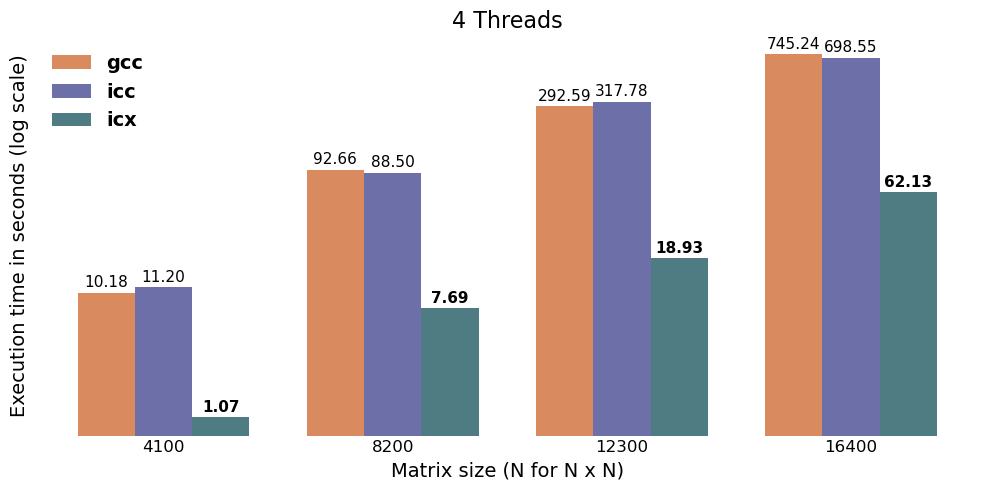

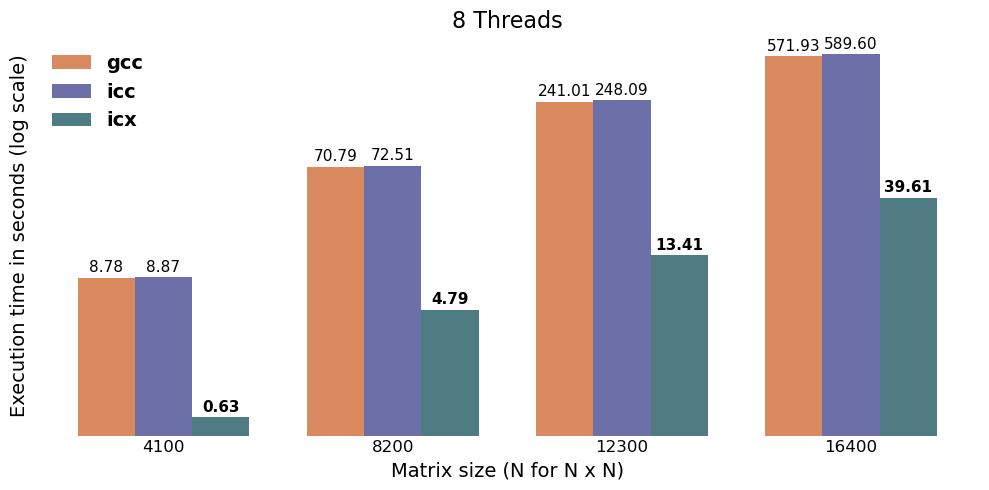

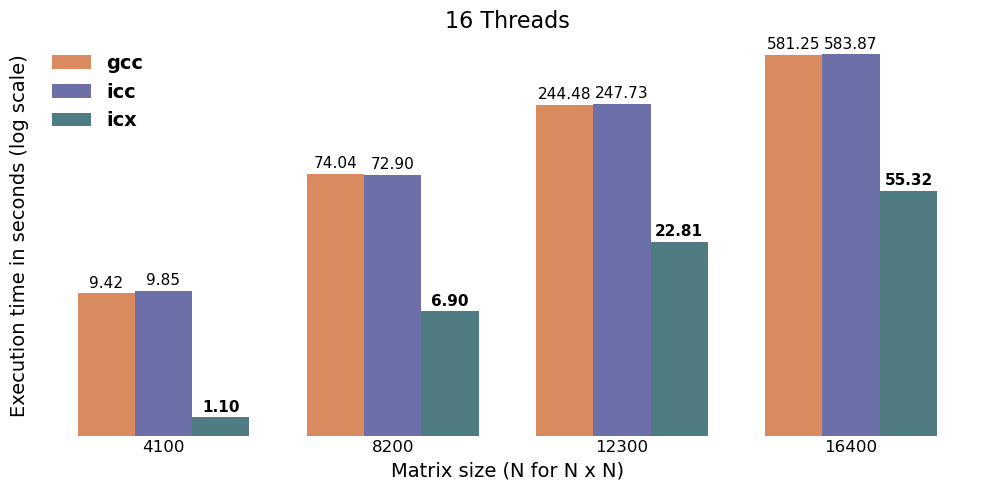

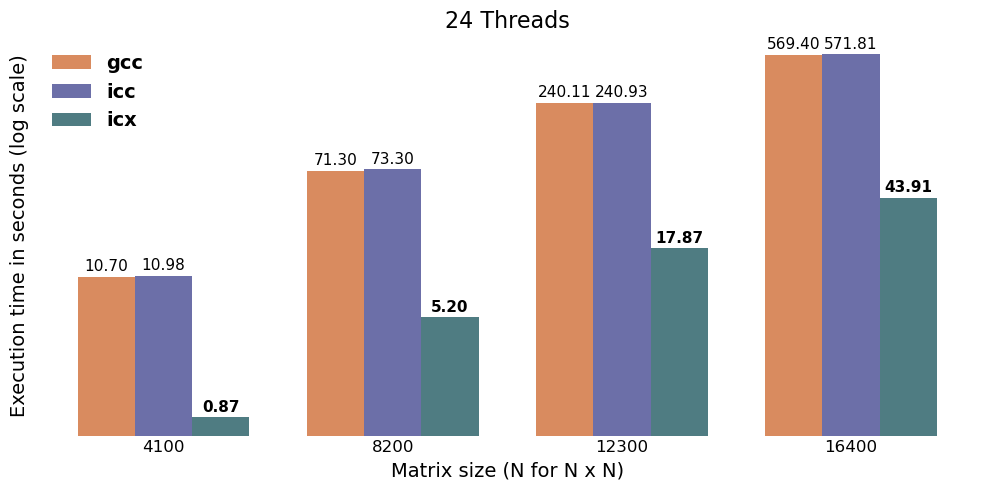

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("benchmark_results_mpi.csv")

# Custom color palette
colors = [
    "#D98B5F",  # warm orange
    "#6C6FA8",  # muted purple
    "#4F7C82",  # desaturated teal
]

selected_sizes = [4100, 8200, 12300, 16400]
thread_values = [4, 8, 16, 24]

filtered = df[
    (df["Test"] == "mpi-ikj") &
    (df["Compiler"].isin(["gcc", "icc", "icx"])) &
    (df["N"].isin(selected_sizes)) &
    (df["Threads/Ranks"].isin(thread_values))
].copy()

filtered = filtered.sort_values(["Threads/Ranks", "N", "Compiler"])

bar_width = 0.25
x = np.arange(len(selected_sizes))

for threads in thread_values:
    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    thread_df = filtered[filtered["Threads/Ranks"] == threads]

    gcc_times = []
    icc_times = []
    icx_times = []

    for n in selected_sizes:
        gcc_row = thread_df[(thread_df["Compiler"] == "gcc") & (thread_df["N"] == n)]
        icc_row = thread_df[(thread_df["Compiler"] == "icc") & (thread_df["N"] == n)]
        icx_row = thread_df[(thread_df["Compiler"] == "icx") & (thread_df["N"] == n)]

        gcc_times.append(gcc_row["Time_s"].iloc[0] if not gcc_row.empty else np.nan)
        icc_times.append(icc_row["Time_s"].iloc[0] if not icc_row.empty else np.nan)
        icx_times.append(icx_row["Time_s"].iloc[0] if not icx_row.empty else np.nan)

    bars_gcc = ax.bar(
        x - bar_width,
        gcc_times,
        width=bar_width,
        label="gcc",
        color=colors[0],
        edgecolor="none"
    )

    bars_icc = ax.bar(
        x,
        icc_times,
        width=bar_width,
        label="icc",
        color=colors[1],
        edgecolor="none"
    )

    bars_icx = ax.bar(
        x + bar_width,
        icx_times,
        width=bar_width,
        label="icx",
        color=colors[2],
        edgecolor="none"
    )

    # Log scale on Y axis
    ax.set_yscale("log")

    # Titles and labels
    ax.set_title(f"{threads} Threads", fontsize=16)
    ax.set_xlabel("Matrix size (N for N x N)", fontsize=14)
    ax.set_ylabel("Execution time in seconds (log scale)", fontsize=14)

    # X ticks
    ax.set_xticks(x)
    ax.set_xticklabels([str(n) for n in selected_sizes], fontsize=12)

    # Remove everything on Y axis except the label
    ax.set_yticks([])
    ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, length=0)

    # Remove black axis lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Remove X tick marks but keep labels
    ax.tick_params(axis="x", length=0)

    # Remove grid
    ax.grid(False)

    # Legend
    ax.legend(frameon=False, loc="upper left", prop={"size": 14, "weight": "bold"})

    # Add value labels and bold the minimum value in each matrix-size group
    for i in range(len(selected_sizes)):
        values = [gcc_times[i], icc_times[i], icx_times[i]]
        min_value = np.nanmin(values)

        current_bars = [bars_gcc[i], bars_icc[i], bars_icx[i]]

        for bar, value in zip(current_bars, values):
            if not np.isnan(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value * 1.05,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    fontweight="bold" if value == min_value else "normal"
                )

    plt.tight_layout()
    plt.show()

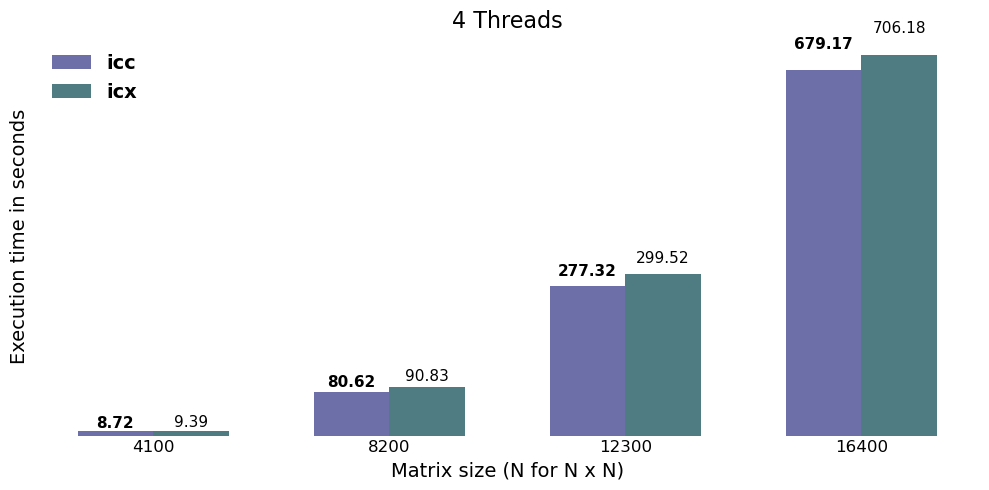

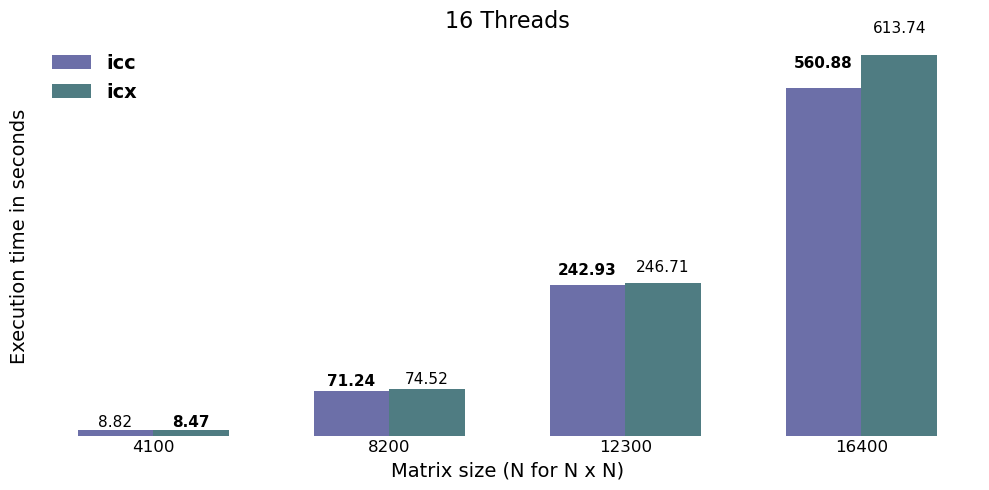

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("benchmark_results_mpi.csv")

# Custom color palette
colors = [
    "#6C6FA8",  # icc
    "#4F7C82",  # icx
]

selected_sizes = [4100, 8200, 12300, 16400]
thread_values = [4, 16]

filtered = df[
    (df["Test"] == "mpi-cannon") &
    (df["Compiler"].isin(["icc", "icx"])) &
    (df["N"].isin(selected_sizes)) &
    (df["Threads/Ranks"].isin(thread_values))
].copy()

filtered = filtered.sort_values(["Threads/Ranks", "N", "Compiler"])

bar_width = 0.32
x = np.arange(len(selected_sizes))

for threads in thread_values:
    fig, ax = plt.subplots(figsize=(10, 5))

    thread_df = filtered[filtered["Threads/Ranks"] == threads]

    icc_times = []
    icx_times = []

    for n in selected_sizes:
        icc_row = thread_df[(thread_df["Compiler"] == "icc") & (thread_df["N"] == n)]
        icx_row = thread_df[(thread_df["Compiler"] == "icx") & (thread_df["N"] == n)]

        icc_times.append(icc_row["Time_s"].iloc[0] if not icc_row.empty else np.nan)
        icx_times.append(icx_row["Time_s"].iloc[0] if not icx_row.empty else np.nan)

    # Barre affiancate
    bars_icc = ax.bar(
        x,
        icc_times,
        width=bar_width,
        label="icc",
        color=colors[0],
        edgecolor="none"
    )

    bars_icx = ax.bar(
        x + bar_width,
        icx_times,
        width=bar_width,
        label="icx",
        color=colors[1],
        edgecolor="none"
    )

    # Titoli e labels
    ax.set_title(f"{threads} Threads", fontsize=16)
    ax.set_xlabel("Matrix size (N for N x N)", fontsize=14)
    ax.set_ylabel("Execution time in seconds", fontsize=14)

    # X ticks centrati sul gruppo di 2 barre
    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels([str(n) for n in selected_sizes], fontsize=12)

    # Remove everything on Y axis except the label
    ax.set_yticks([])
    ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, length=0)

    # Remove black axis lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Remove X tick marks but keep labels
    ax.tick_params(axis="x", length=0)

    # Remove grid
    ax.grid(False)

    # Legend
    ax.legend(frameon=False, loc="upper left", prop={"size": 14, "weight": "bold"})

    # Add value labels centered INSIDE each bar
    # Bold the minimum value between icc and icx for each matrix size
    for i in range(len(selected_sizes)):
        values = [icc_times[i], icx_times[i]]
        min_value = np.nanmin(values)

        current_bars = [bars_icc[i], bars_icx[i]]

        for bar, value in zip(current_bars, values):
            if not np.isnan(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value * 1.05,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    fontweight="bold" if value == min_value else "normal"
                )

    plt.tight_layout()
    plt.show()

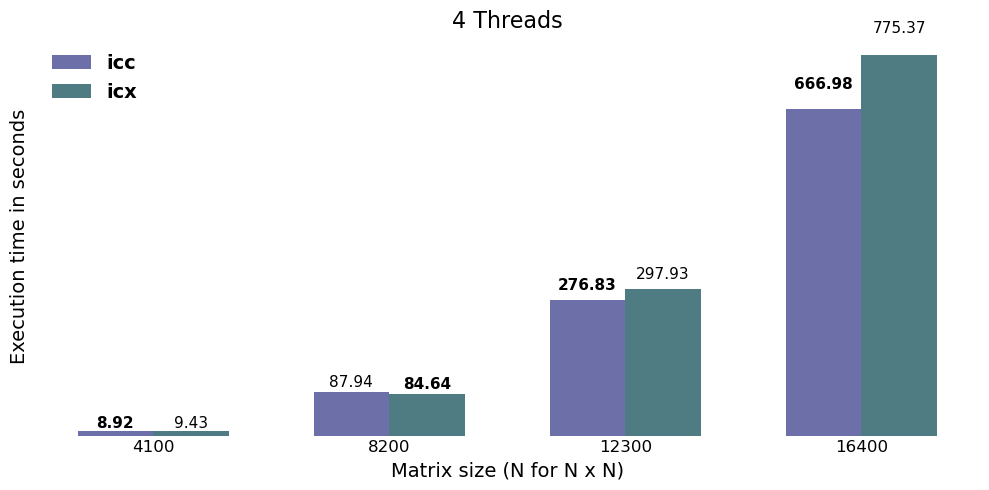

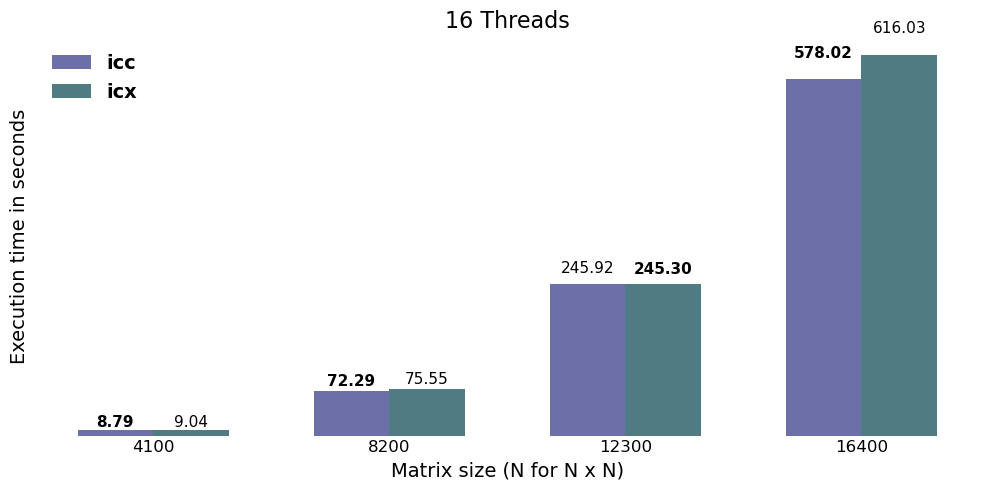

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("benchmark_results_mpi.csv")

# Custom color palette
colors = [
    "#6C6FA8",  # icc
    "#4F7C82",  # icx
]

selected_sizes = [4100, 8200, 12300, 16400]
thread_values = [4, 16]

filtered = df[
    (df["Test"] == "mpi-summa") &
    (df["Compiler"].isin(["icc", "icx"])) &
    (df["N"].isin(selected_sizes)) &
    (df["Threads/Ranks"].isin(thread_values))
].copy()

filtered = filtered.sort_values(["Threads/Ranks", "N", "Compiler"])

bar_width = 0.32
x = np.arange(len(selected_sizes))

for threads in thread_values:
    fig, ax = plt.subplots(figsize=(10, 5))

    thread_df = filtered[filtered["Threads/Ranks"] == threads]

    icc_times = []
    icx_times = []

    for n in selected_sizes:
        icc_row = thread_df[(thread_df["Compiler"] == "icc") & (thread_df["N"] == n)]
        icx_row = thread_df[(thread_df["Compiler"] == "icx") & (thread_df["N"] == n)]

        icc_times.append(icc_row["Time_s"].iloc[0] if not icc_row.empty else np.nan)
        icx_times.append(icx_row["Time_s"].iloc[0] if not icx_row.empty else np.nan)

    # Barre affiancate
    bars_icc = ax.bar(
        x,
        icc_times,
        width=bar_width,
        label="icc",
        color=colors[0],
        edgecolor="none"
    )

    bars_icx = ax.bar(
        x + bar_width,
        icx_times,
        width=bar_width,
        label="icx",
        color=colors[1],
        edgecolor="none"
    )

    # Titoli e labels
    ax.set_title(f"{threads} Threads", fontsize=16)
    ax.set_xlabel("Matrix size (N for N x N)", fontsize=14)
    ax.set_ylabel("Execution time in seconds", fontsize=14)

    # X ticks centrati sul gruppo di 2 barre
    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels([str(n) for n in selected_sizes], fontsize=12)

    # Remove everything on Y axis except the label
    ax.set_yticks([])
    ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, length=0)

    # Remove black axis lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Remove X tick marks but keep labels
    ax.tick_params(axis="x", length=0)

    # Remove grid
    ax.grid(False)

    # Legend
    ax.legend(frameon=False, loc="upper left", prop={"size": 14, "weight": "bold"})

    # Add value labels centered INSIDE each bar
    # Bold the minimum value between icc and icx for each matrix size
    for i in range(len(selected_sizes)):
        values = [icc_times[i], icx_times[i]]
        min_value = np.nanmin(values)

        current_bars = [bars_icc[i], bars_icx[i]]

        for bar, value in zip(current_bars, values):
            if not np.isnan(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value * 1.05,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    fontweight="bold" if value == min_value else "normal"
                )

    plt.tight_layout()
    plt.show()

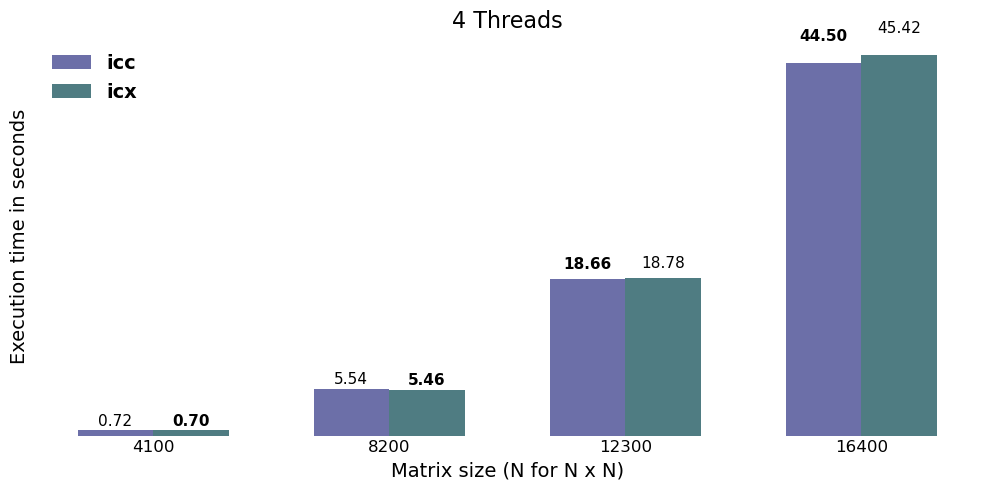

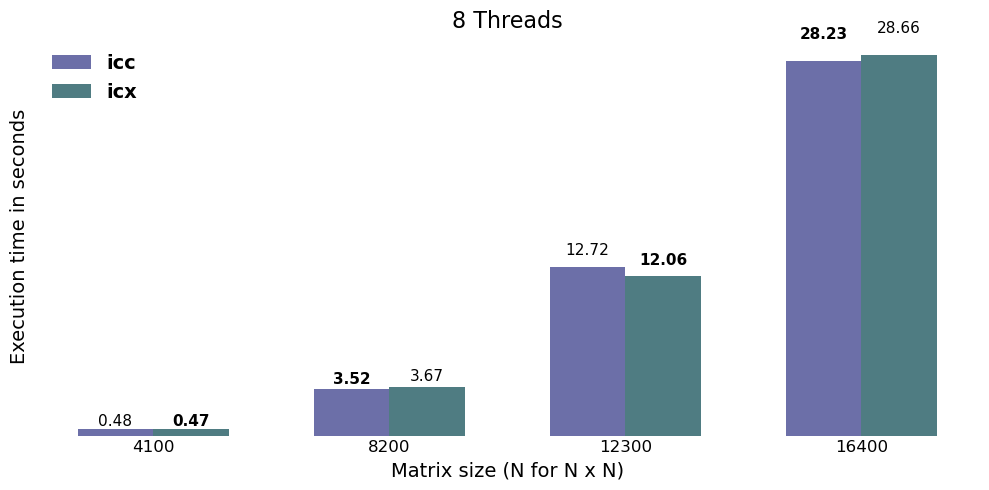

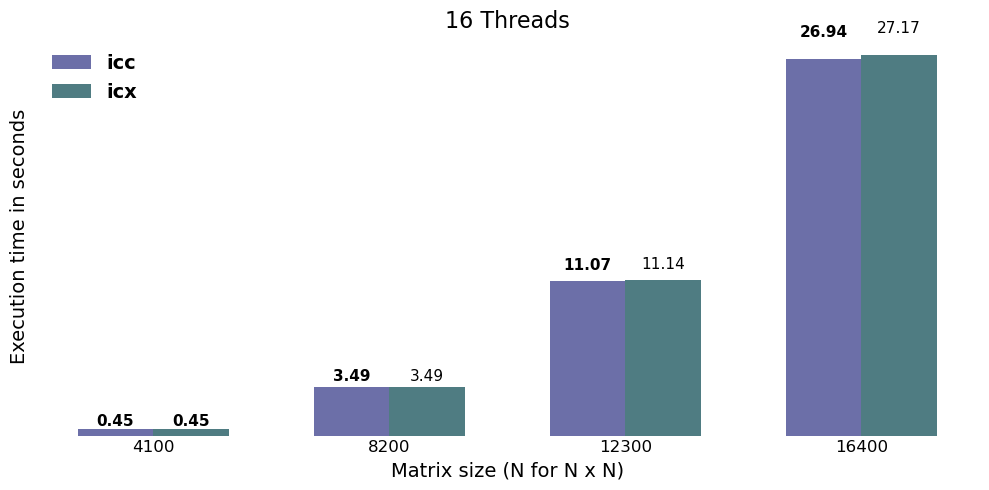

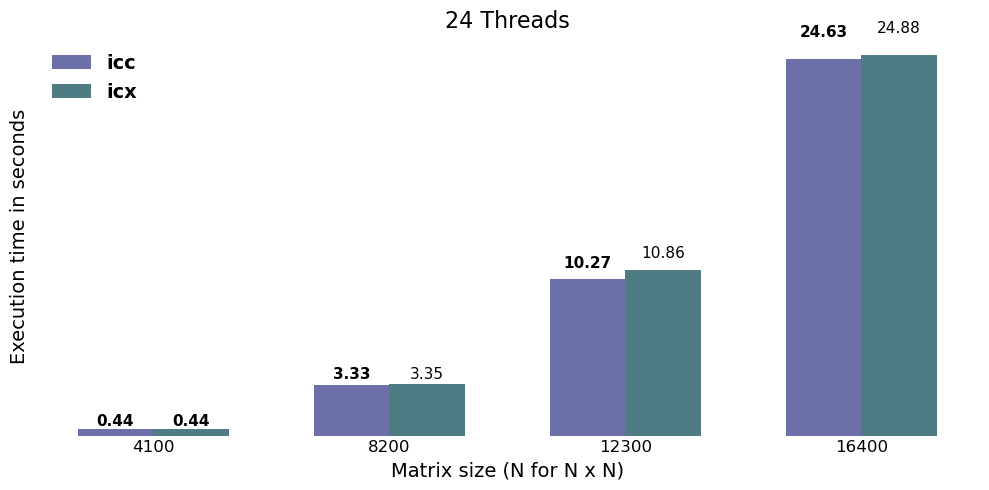

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("benchmark_results_mpi.csv")

# Custom color palette
colors = [
    "#6C6FA8",  # icc
    "#4F7C82",  # icx
]

selected_sizes = [4100, 8200, 12300, 16400]
thread_values = [4,8,16,24]

filtered = df[
    (df["Test"] == "scalapack") &
    (df["Compiler"].isin(["icc", "icx"])) &
    (df["N"].isin(selected_sizes)) &
    (df["Threads/Ranks"].isin(thread_values))
].copy()

filtered = filtered.sort_values(["Threads/Ranks", "N", "Compiler"])

bar_width = 0.32
x = np.arange(len(selected_sizes))

for threads in thread_values:
    fig, ax = plt.subplots(figsize=(10, 5))

    thread_df = filtered[filtered["Threads/Ranks"] == threads]

    icc_times = []
    icx_times = []

    for n in selected_sizes:
        icc_row = thread_df[(thread_df["Compiler"] == "icc") & (thread_df["N"] == n)]
        icx_row = thread_df[(thread_df["Compiler"] == "icx") & (thread_df["N"] == n)]

        icc_times.append(icc_row["Time_s"].iloc[0] if not icc_row.empty else np.nan)
        icx_times.append(icx_row["Time_s"].iloc[0] if not icx_row.empty else np.nan)

    # Barre affiancate
    bars_icc = ax.bar(
        x,
        icc_times,
        width=bar_width,
        label="icc",
        color=colors[0],
        edgecolor="none"
    )

    bars_icx = ax.bar(
        x + bar_width,
        icx_times,
        width=bar_width,
        label="icx",
        color=colors[1],
        edgecolor="none"
    )

    # Titoli e labels
    ax.set_title(f"{threads} Threads", fontsize=16)
    ax.set_xlabel("Matrix size (N for N x N)", fontsize=14)
    ax.set_ylabel("Execution time in seconds", fontsize=14)

    # X ticks centrati sul gruppo di 2 barre
    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels([str(n) for n in selected_sizes], fontsize=12)

    # Remove everything on Y axis except the label
    ax.set_yticks([])
    ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, length=0)

    # Remove black axis lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Remove X tick marks but keep labels
    ax.tick_params(axis="x", length=0)

    # Remove grid
    ax.grid(False)

    # Legend
    ax.legend(frameon=False, loc="upper left", prop={"size": 14, "weight": "bold"})

    # Add value labels centered INSIDE each bar
    # Bold the minimum value between icc and icx for each matrix size
    for i in range(len(selected_sizes)):
        values = [icc_times[i], icx_times[i]]
        min_value = np.nanmin(values)

        current_bars = [bars_icc[i], bars_icx[i]]

        for bar, value in zip(current_bars, values):
            if not np.isnan(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value * 1.05,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    fontweight="bold" if value == min_value else "normal"
                )

    plt.tight_layout()
    plt.show()

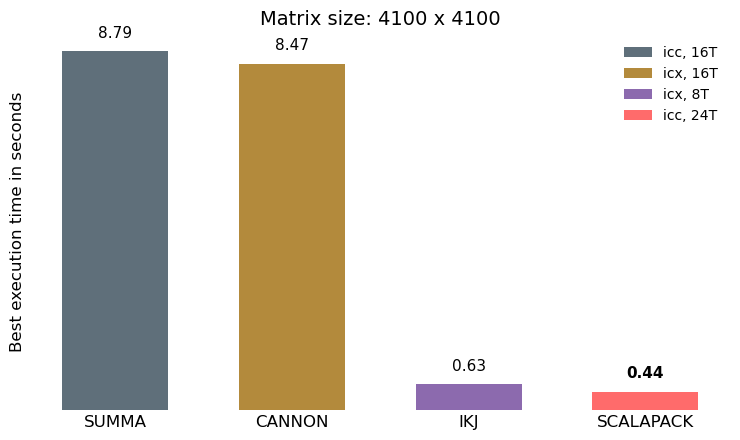

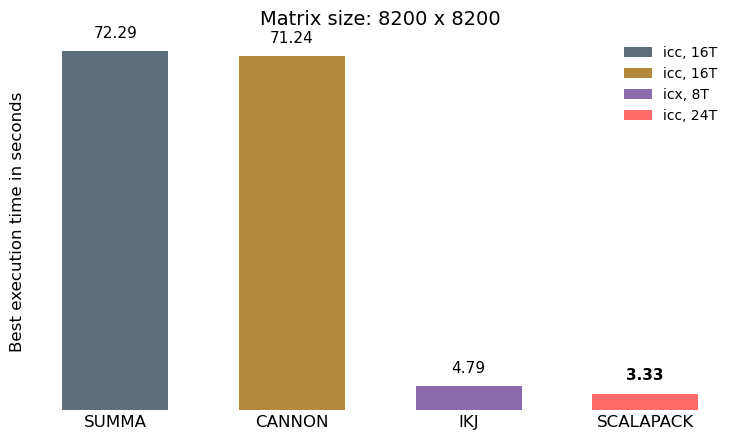

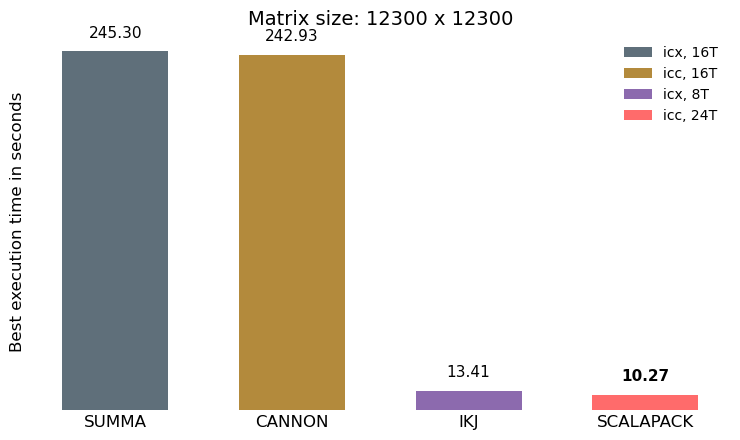

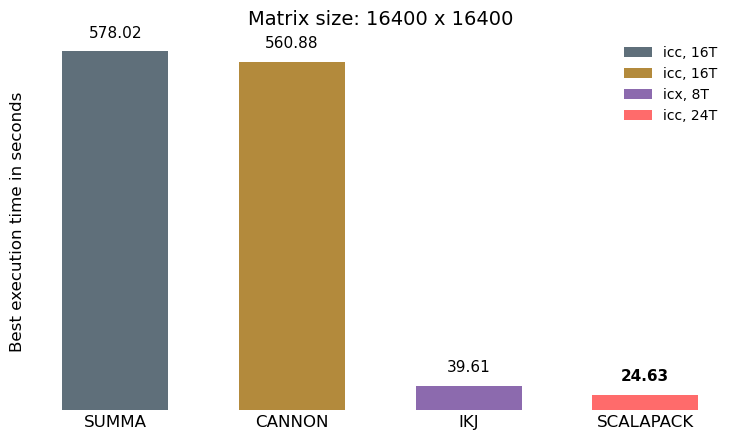

In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- input ---
df = pd.read_csv("benchmark_results_mpi.csv")

selected_sizes = [4100, 8200, 12300, 16400]

# --- pulizia tipi ---
df["Compiler"] = df["Compiler"].astype(str).str.strip().str.lower()
df["Test"] = df["Test"].astype(str).str.strip().str.lower()
df["N"] = pd.to_numeric(df["N"], errors="coerce")
df["Threads/Ranks"] = pd.to_numeric(df["Threads/Ranks"], errors="coerce")
df["Time_s"] = pd.to_numeric(df["Time_s"], errors="coerce")
df["TileSize_num"] = pd.to_numeric(df["TileSize"], errors="coerce")  # "-" -> NaN

# --- classificazione approccio ---
def classify_approach(row) -> str:
    t = row["Test"]
    tile_num = row["TileSize_num"]
    if "ikj" in t:
        return "ikj"
    if "cannon" in t:
        return "cannon"
    if "summa" in t:
        return "summa"
    if "scalapack" in t:
        return "scalapack"
    return "other"

df["approach"] = df.apply(classify_approach, axis=1)

# --- colori (3 barre) ---
colors = {
    "ikj":  "#8C6AAE",  # purple
    "cannon": "#B38A3C",  # green
    "summa":  "#5F6F7A",  # teal
    "scalapack":  "#FF6B6B",  # red
}

def best_row_per_approach(sub: pd.DataFrame):
    """
    Ritorna dict: approach -> (best_time, row_best)
    best_time = min Time_s su TUTTE le configurazioni (compiler/threads/tile)
    """
    out = {}
    for a in [ "cannon", "ikj","summa", "scalapack"]:
        tmp = sub[sub["approach"] == a].dropna(subset=["Time_s"])
        if tmp.empty:
            out[a] = (np.nan, None)
        else:
            idx = tmp["Time_s"].idxmin()
            out[a] = (float(tmp.loc[idx, "Time_s"]), tmp.loc[idx])
    return out

def format_cfg(row, approach):
    if row is None:
        return "no data"
    comp = row["Compiler"]
    th = int(row["Threads/Ranks"]) if pd.notna(row["Threads/Ranks"]) else None
    if approach == "tile":
        ts = int(row["TileSize_num"]) if pd.notna(row["TileSize_num"]) else None
        if th is not None and ts is not None:
            return f"{comp}, {th}T, tile={ts}"
        if th is not None:
            return f"{comp}, {th}T"
        return f"{comp}"
    else:
        if th is not None:
            return f"{comp}, {th}T"
        return f"{comp}"

def minimal_style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)   # <-- linea asse X via

    # remove y numbers/ticks
    ax.set_yticks([])                        # <-- numeri asse Y via
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)
    ax.grid(False)

# --- 4 plot: uno per N ---
for N in selected_sizes:
    sub = df[df["N"] == N].copy()

    best = best_row_per_approach(sub)

    approaches = [ "summa","cannon","ikj",  "scalapack"]
    times = [best[a][0] for a in approaches]

    # best overall (tra i tre)
    finite_times = [(a, t) for a, t in zip(approaches, times) if np.isfinite(t)]
    if finite_times:
        best_overall_a, best_overall_t = min(finite_times, key=lambda x: x[1])
        title = f"Matrix size: {N} x {N}"
    else:
        title = f"Matrix size: {N} x {N} —  no data"

    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    x = np.arange(len(approaches))
    barlist = ax.bar(
        x, times,
        color=[colors[a] for a in approaches],
        edgecolor="none",
        width=0.60
    )

    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Best execution time in seconds", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([a.upper() for a in approaches], fontsize=12)

    # legenda con "migliore prestazione" (tempo + config)
    handles = []
    labels = []
    for a in approaches:
        t, row = best[a]
        if np.isfinite(t):
            labels.append(f"{format_cfg(row, a)}")
        else:
            labels.append(f"{a.upper()} — no data")
        handles.append(barlist[approaches.index(a)])

    ax.legend(handles, labels, frameon=False, loc="upper right", fontsize=10)

    # valori sopra le barre (come prima)
    # + grassetto sulla barra migliore (tempo MIN) tra i tre
    if finite_times:
        best_min_t = best_overall_t
    else:
        best_min_t = None

    # offset “robusto” per posizione testo
    max_t = np.nanmax(times) if np.any(np.isfinite(times)) else 0.0
    offset = max_t * 0.03 if max_t > 0 else 0.0

    for bar, a, t in zip(barlist, approaches, times):
        if np.isfinite(t):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                t + offset,
                f"{t:.2f}",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold" if (best_min_t is not None and np.isclose(t, best_min_t)) else "normal"
            )

    minimal_style(ax)
    plt.tight_layout()
    plt.show()